In [36]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def compute_stall_boundary(V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref):
    print("Computing stall boundary...")
    stall_coeff = 0.5 * rho_sl * CL_max / (Weight / S_ref)
    print(f"W/S: {Weight / S_ref:.3f} lb/ft^2")
    print(f"Stall coefficient: {stall_coeff:.6f}")

    V = np.linspace(V_min, V_max, n_points)
    n_Stall = stall_coeff * V**2

    return V, n_Stall, stall_coeff

rho_sl = 0.002377    # slugs/ft^3 (sea level)
rho_30k = 0.000889   # slugs/ft^3 at 30,000 ft

V_max_TAS = 2000     # ft/s calculated from Mach 2.0 at 30,000 ft altitude
V_max = V_max_TAS * np.sqrt(rho_30k / rho_sl)
V_min = 0            # ft/s

print(f"Converted V_max (EAS): {V_max:.2f} ft/s")

n_points = 100

CL_max = 1.6

MTOW_lb = 0     # [set to 0 if doing min case] change for mission type (strike=36796.33) (a2a=33953.47)
minTOW_lb = 0   # [set to 0 if doing max case] change for mission type (strike=22489.32) (a2a=22404.03)
Weight = MTOW_lb + minTOW_lb    # lbf
S_ref = 400   # ft^2 

# --- RUN ---
Boundary_V, Boundary_n_Stall, stall_coeff = compute_stall_boundary(
    V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref
)

V = np.linspace(V_min, V_max, n_points)


Converted V_max (EAS): 1223.11 ft/s
Computing stall boundary...
W/S: 56.010 lb/ft^2
Stall coefficient: 0.000034


In [55]:
n_pos_limit = 7   # set to 7 or 8g according to goal
n_pos_limit = np.ones(100)*n_pos_limit
print(f"Positive limit load facotr: {n_pos_limit[0]:.2f}")

# Under MIL-A-8861, the negative limit load factor is generally specified as:
n_neg_limit = -0.4 * n_pos_limit * np.ones(100)
print(f"Negative limit load factor: {n_neg_limit[0]:.2f}")

# Characteristic speeds (EAS)

# Stall speed (n = 1)
V_s = np.sqrt(1 / stall_coeff)

# Maneuvering speed (positive limit load factor)
V_A = np.sqrt(n_pos_limit[0] / stall_coeff)

# Dive speed (your max envelope speed, already EAS converted)
V_D = V_max

print(f"Vs = {V_s:.2f} ft/s")
print(f"VA = {V_A:.2f} ft/s")
print(f"VD = {V_D:.2f} ft/s")


Positive limit load facotr: 7.00
Negative limit load factor: -2.80
Vs = 171.62 ft/s
VA = 454.07 ft/s
VD = 1223.11 ft/s


In [56]:
def compute_intersection_velocity(stall_coeff, n_limit):
    """
    Solve stall_coeff * V^2 = |n_limit|
    """
    int_V = np.sqrt(abs(n_limit) / stall_coeff)
    print(f"Intersection velocity for n_limit={n_limit:.2f} is {int_V:.2f} ft/s")
    return int_V

# Compute intersection velocities for positive and negative limit load factors with in the stall boundary
V_stall_pos_end = compute_intersection_velocity(stall_coeff, n_pos_limit[0])
V_stall_pos = np.linspace(0, V_stall_pos_end, 100)

V_stall_neg_end = compute_intersection_velocity(stall_coeff, n_neg_limit[0])
V_stall_neg = np.linspace(0, V_stall_neg_end, 100)

# Compute the corresponding n values at the intersection points
n_stall_pos_intersection = stall_coeff * V_stall_pos**2
n_stall_neg_intersection = -stall_coeff * V_stall_neg**2


Intersection velocity for n_limit=7.00 is 454.07 ft/s
Intersection velocity for n_limit=-2.80 is 287.18 ft/s


In [57]:
# Extend the positive limit load line to the right of the intersection point
V_pos_limit_extended = np.linspace(V_stall_pos_end, V_max, 100)
V_neg_limit_extended = np.linspace(V_stall_neg_end, V_max, 100)
n_pos_extended = n_pos_limit[0] * np.ones_like(V_pos_limit_extended)
n_neg_extended = n_neg_limit[0] * np.ones_like(V_neg_limit_extended)


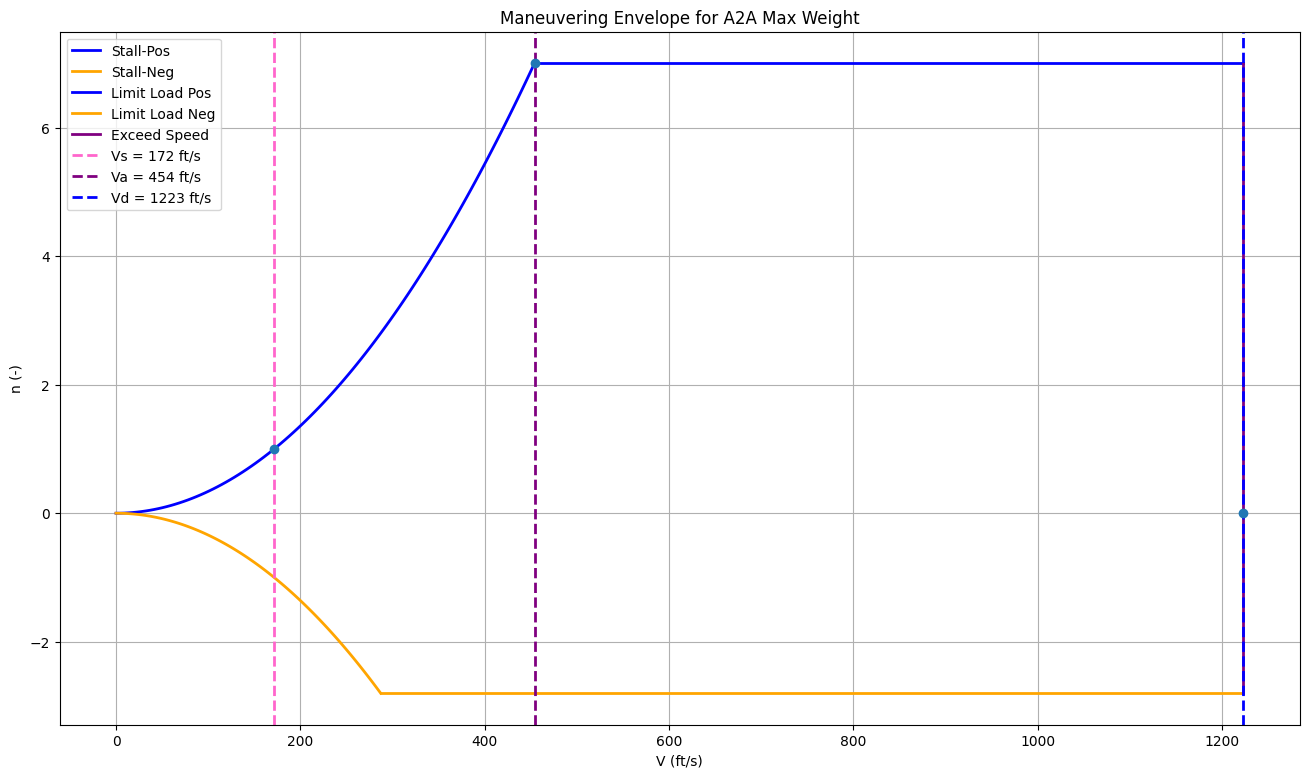

In [58]:
# Plot the exceed speed lines
V_exceed = V_max 

n_exceed_line = np.linspace(n_neg_limit[0], n_pos_limit[0], 100)
V_exceed_line = V_exceed * np.ones_like(n_exceed_line)


plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope for A2A Max Weight')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.plot(V_exceed_line, n_exceed_line,label='Exceed Speed', linewidth=2, color='purple')
# --- Key characteristic speeds ---
plt.axvline(V_s, linestyle='--', color='#ff66cc', linewidth=2, label=f'Vs = {V_s:.0f} ft/s')
plt.axvline(V_A, linestyle='--', color='purple', linewidth=2, label=f'Va = {V_A:.0f} ft/s')
plt.axvline(V_D, linestyle='--', color='blue', linewidth=2, label=f'Vd = {V_D:.0f} ft/s')

# Optional markers at n=1 line for clarity
plt.scatter([V_s, V_A, V_D], [1, n_pos_limit[0], 0],
            zorder=5)
plt.grid(True)
plt.legend(loc='best')
plt.show()